# 01_collection_phase2B_v1 — KCGS stratified 30건 batch (사이클 3)

> **이전**: phase2A_v2 (Samsung 1건) Run All 성공 → 본 phase2B는 30건 batch 확장
> **작성자**: 이동원 · **작성일**: 2026-05-18 · **버전**: v1 (신설)
> **목표**: KCGS 등급별 stratified 5건 × 6등급 = 30건 firm-year batch 수집
> **벤치마킹 5번 (arXiv 2208.01712)**: N≥30 + stratified 가 ML/회귀 통계 추정 최소 기준

---

## 📚 본 노트북의 위치

phase2A_v2가 Samsung 1건으로 풀 파이프 검증 완료. 이제 02_preprocessing v3 + 03_mining v2 입력으로 사용할 N=30 corpus 확보. **이 시점부터 Spearman ρ + OLS β 통계 의미 발생**.

## 🛡️ 위반금지 매핑 (가이드 02·04)

| # | 위반금지 | 본 v1 준수 |
|---|---|---|
| 1 | 실패 행 가짜 0 ❌ | try/except로 status=FAIL_* + reason 명시. SUCCESS 행만 esg_features에 join |
| 2 | viewer 우회 ❌ | document.xml API + viewer URL 컬럼 |
| 3 | MCP/추출 그대로 신뢰 ❌ | 30건 중 random 3개 viewer 확인 셀 명시 |
| 4 | API key 출력 노출 ❌ | mask_key + KEY_CANDIDATES (phase2A_v2 함수 reuse) |
| 5 | raw 미보존 ❌ | data/raw/*.zip 30개 보존 |
| 6 | 진단 부재 ❌ | per-firm progress + SUCCESS/FAIL counter + 등급별 분포 시각화 |
| 7 | silent 오매칭 ❌ | stock_code dtype=str zfill(6) 강제 |
| 8 | 평가 기준 부재 ❌ | SUCCESS ≥ 80% (24건+) 목표 명시 |

## 🗺️ Step

| Step | What | 시간 추정 |
|---|---|---|
| 1 | 환경 + Fix A/E + phase2A_v2 의존 함수 inline 정의 | 10초 |
| 2 | 30건 stratified sample 선택 (등급별 5건) | 5초 |
| 3 | batch run_one_firm_year × 30 (rate limit 1.0 req/s) | 5~10분 |
| 4 | collection_log dedup + run_id + section_match 저장 | 5초 |
| 5 | random 3건 viewer 검증 셀 | 사용자 수동 |
| 6 | 등급별 SUCCESS 분포 시각화 + self-check | 10초 |


---
## 🔧 사이클 2 안정성 fix (Fix A + Fix E)


In [1]:
import matplotlib
from matplotlib import font_manager
import pandas as pd

def setup_korean_font(verbose=True):
    preferred = ['Malgun Gothic','NanumGothic','AppleGothic','Noto Sans CJK KR','Noto Sans KR']
    try: font_manager._load_fontmanager(try_read_cache=False)
    except: pass
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((p for p in preferred if p in available), None)
    if chosen:
        matplotlib.rcParams['font.family'] = chosen
        matplotlib.rcParams['axes.unicode_minus'] = False
        if verbose: print(f'✅ 한글 폰트: {chosen}')
    return chosen

KOREAN_FONT = setup_korean_font()
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_columns', 30)


✅ 한글 폰트: Malgun Gothic


---
## Step 1 — 환경 + phase2A_v2 의존 함수 inline 정의

### What
phase2A_v2 검증된 함수 5종 inline 정의 (corp_map · fetch_rcept_no · fetch_disclosure_zip · classify_xml_in_zip · extract_sections_v2 · extract_passages_v2).

### Why
가이드 04 §2-1: 외부 모듈 import 없이 Run All 재현. 함수는 v2와 동일.


In [2]:
import os, re, json, time, zipfile, hashlib, warnings
from copy import deepcopy
from io import BytesIO
from pathlib import Path
from datetime import datetime
from typing import Any

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from dotenv import load_dotenv

def find_project_root(start=None):
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'data' / 'company_master.csv').exists():
            return parent
    raise RuntimeError('루트 찾기 실패')

ROOT = find_project_root()
load_dotenv(ROOT / '.env')
KEY_CANDIDATES = ['OPENDART_API_KEY', 'API_KEY', 'DART_API_KEY']
API_KEY = next((os.getenv(k) for k in KEY_CANDIDATES if os.getenv(k)), None)
assert API_KEY, '❌ API key 없음'

def mask_key(k): return f'{k[:4]}...len={len(k)}' if k else '<MASKED>'
print(f'✅ API key {mask_key(API_KEY)}')

RAW_DIR = ROOT / 'data' / 'raw'
INTERIM_DIR = ROOT / 'data' / 'interim'
CACHE_DIR = ROOT / 'data' / 'cache'
LOGS_DIR = ROOT / 'logs'
for d in (RAW_DIR, INTERIM_DIR, CACHE_DIR, LOGS_DIR):
    d.mkdir(parents=True, exist_ok=True)

PARSER_VERSION = 'v3_batch'
RUN_DATE = datetime.now().strftime('%Y-%m-%d')
RUN_ID = hashlib.md5(f'{RUN_DATE}_{PARSER_VERSION}_seed42'.encode()).hexdigest()[:8]
print(f'🆔 run_id: {RUN_ID} (parser={PARSER_VERSION})')

# ─── phase2A_v2 검증 함수 inline 정의 ───
from lxml import etree

SECTION_CODE_MAP = {
    'CEO_CERT': ('TTL_CEO_CERT', '대표이사 등의 확인'),
    'I':   ('010000', 'I. 회사의 개요'),
    'II':  ('020000', 'II. 사업의 내용'),
    'III': ('030000', 'III. 재무에 관한 사항'),
    'IV':  ('040000', 'IV. 이사의 경영진단 및 분석의견'),
    'V':   ('050000', 'V. 회계감사인의 감사의견 등'),
    'VI':  ('060000', 'VI. 이사회 등 회사의 기관에 관한 사항'),
    'VII': ('070000', 'VII. 주주에 관한 사항'),
    'VIII':('080000', 'VIII. 임원 및 직원 등에 관한 사항'),
    'IX':  ('090000', 'IX. 계열회사 등에 관한 사항'),
    'X':   ('100000', 'X. 대주주 등과의 거래내용'),
    'XI':  ('110000', 'XI. 그 밖에 투자자 보호를 위하여 필요한 사항'),
    'APPENDIX': ('TTL_APPENDIX', 'XII. 상세표'),
    'EXPERT': (None, '【 전문가의 확인 】'),
}
ESG_TARGET_LABELS = ['II', 'IV', 'VI']
AASSOC_TO_LABEL = {
    'D-0-1-0-0':'I','D-0-2-0-0':'II','D-0-3-0-0':'III','D-0-4-0-0':'IV','D-0-5-0-0':'V',
    'D-0-6-0-0':'VI','D-0-7-0-0':'VII','D-0-8-0-0':'VIII','D-0-9-0-0':'IX',
    'D-0-10-0-0':'X','D-0-11-0-0':'XI',
}
DOC_TYPE_PATTERN = re.compile(r'<DOCUMENT-NAME[^>]*>([^<]+)</DOCUMENT-NAME>', re.UNICODE)

def fetch_corp_code_map(api_key, cache_dir):
    cache_path = cache_dir / 'corp_code_map.parquet'
    if cache_path.exists():
        df = pd.read_parquet(cache_path)
        return df
    res = requests.get('https://opendart.fss.or.kr/api/corpCode.xml',
                       params={'crtfc_key': api_key}, timeout=30)
    res.raise_for_status()
    with zipfile.ZipFile(BytesIO(res.content)) as zf:
        xml_text = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    root = etree.fromstring(xml_text.encode('utf-8'))
    rows = []
    for item in root.findall('.//list'):
        sc = (item.findtext('stock_code') or '').strip()
        if sc and sc != ' ':
            rows.append({'corp_code': item.findtext('corp_code'),
                         'corp_name': item.findtext('corp_name'),
                         'stock_code': sc.zfill(6)})
    df = pd.DataFrame(rows)
    df.to_parquet(cache_path, index=False)
    return df

def fetch_rcept_no(api_key, corp_code, fiscal_year):
    submit_year = fiscal_year + 1
    params = {'crtfc_key': api_key, 'corp_code': corp_code,
              'bgn_de': f'{submit_year}0101', 'end_de': f'{submit_year}1231',
              'pblntf_detail_ty': 'A001', 'page_count': '100'}
    res = requests.get('https://opendart.fss.or.kr/api/list.json', params=params, timeout=20)
    res.raise_for_status()
    rows = res.json().get('list', [])
    tgt = f'({fiscal_year}.12)'
    primary = [r for r in rows if '사업보고서' in r.get('report_nm','') and tgt in r.get('report_nm','') and '정정' not in r.get('report_nm','')]
    corr = [r for r in rows if '사업보고서' in r.get('report_nm','') and tgt in r.get('report_nm','') and '정정' in r.get('report_nm','')]
    if primary: chosen, fb = primary[0], 'PRIMARY_BIZ'
    elif corr: chosen, fb = corr[0], 'CORR_BIZ'
    else:
        any_biz = [r for r in rows if '사업보고서' in r.get('report_nm','')]
        if not any_biz: return {'rcept_no': None, 'fallback_used': None}
        chosen, fb = any_biz[0], 'ANY_BIZ'
    return {'rcept_no': chosen['rcept_no'], 'rcept_dt': chosen['rcept_dt'],
            'report_nm': chosen['report_nm'], 'fallback_used': fb}

def fetch_disclosure_zip(api_key, rcept_no, stock_code, fiscal_year, raw_dir):
    zip_path = raw_dir / f'{stock_code}_{fiscal_year}_disclosure.zip'
    if zip_path.exists():
        return zip_path
    res = requests.get('https://opendart.fss.or.kr/api/document.xml',
                       params={'crtfc_key': api_key, 'rcept_no': rcept_no}, timeout=30)
    res.raise_for_status()
    zip_path.write_bytes(res.content)
    return zip_path

def classify_xml_in_zip(zip_path):
    classified = {}
    with zipfile.ZipFile(zip_path) as zf:
        for name in zf.namelist():
            if not name.endswith('.xml'): continue
            raw = zf.read(name).decode('utf-8', errors='ignore')
            m = DOC_TYPE_PATTERN.search(raw[:500])
            doc_type = m.group(1).strip() if m else 'UNKNOWN'
            classified[doc_type] = raw
    return classified

def extract_sections_v2(xml_text):
    root = etree.fromstring(xml_text.encode('utf-8'))
    sections_all = {}
    for idx, sec1 in enumerate(root.findall('.//SECTION-1')):
        title_elem = sec1.find('.//TITLE')
        title_text = ''.join(title_elem.itertext()).strip() if title_elem is not None else ''
        aassocnote = sec1.get('AASSOCNOTE', '') or ''
        label, method = None, 'no_match'
        if aassocnote in AASSOC_TO_LABEL:
            label, method = AASSOC_TO_LABEL[aassocnote], 'AASSOCNOTE'
        else:
            for k, (code, title_pat) in SECTION_CODE_MAP.items():
                if title_pat in title_text:
                    label, method = k, 'TITLE_text'
                    break
        if label is None:
            label = f'UNK_{idx}'
        tables_text_list = [''.join(tbl.itertext()) for tbl in sec1.findall('.//TABLE')]
        tables_text = ' '.join(tables_text_list).strip()
        full_text = ''.join(sec1.itertext()).strip()
        body_text = full_text.replace(tables_text, '').strip() if tables_text else full_text
        section_code = SECTION_CODE_MAP.get(label, (None, None))[0] if not label.startswith('UNK') else None
        sections_all[label] = {
            'sec1_index': idx, 'section_code': section_code, 'title_text': title_text,
            'aassocnote': aassocnote, 'method': method,
            'text_char_count': len(full_text), 'body_text': body_text,
            'body_char_count': len(body_text), 'tables_text': tables_text,
            'tables_char_count': len(tables_text), 'n_tables': len(tables_text_list),
        }
    return sections_all

def extract_passages_v2(target_sections, seed_df, stock_code, fiscal_year, source='body', min_len=20):
    seed_patterns = {row['seed_term']: (re.compile(row['pattern']), row['dimension'])
                     for _, row in seed_df.iterrows()}
    source_key = 'body_text' if source == 'body' else 'tables_text'
    rows = []
    for label in ESG_TARGET_LABELS:
        if label not in target_sections: continue
        sec = target_sections[label]
        txt = sec[source_key]
        sentences = re.split(r'(?<=[.!?])\s+|\n', txt)
        for s in sentences:
            s = s.strip()
            if len(s) < min_len: continue
            matched, dims = [], set()
            for term, (pat, dim) in seed_patterns.items():
                if pat.search(s):
                    matched.append(term)
                    dims.add(dim)
            if matched:
                rows.append({'stock_code': stock_code, 'fiscal_year': fiscal_year,
                             'section': label, 'section_code': sec['section_code'],
                             'sentence': s, 'dimensions': '|'.join(sorted(dims)),
                             'matched_terms': '|'.join(sorted(matched)),
                             'n_matches': len(matched)})
    return pd.DataFrame(rows)

print(f'✅ phase2A_v2 함수 5종 inline 로딩 완료')


✅ API key 0e1e...len=40
🆔 run_id: b2252620 (parser=v3_batch)
✅ phase2A_v2 함수 5종 inline 로딩 완료


---
## Step 2 — 30건 stratified sample 선택 (KCGS 등급별 5건)

### What
company_master에서 esg_grade 등급별 5건씩 random sample. S 등급은 부족 시 가용 전체.

### Why
- 벤치마킹 5번: N≥30 + stratified가 회귀 통계 최소 조건
- 가이드 03 §3 평가표 "Spearman ρ 0.10~0.20 약한 연관성" 검출 위해 등급 분산 필요

### 근거
- seed=42 고정 (재현성)
- Samsung 005930×2024는 phase2A_v2에 이미 수집 → 본 batch에서 제외


In [3]:
cm = pd.read_csv(ROOT / 'data' / 'company_master.csv', dtype={'stock_code': str})
cm['stock_code'] = cm['stock_code'].str.zfill(6)
print(f'📊 company_master: {len(cm)}행')

# Samsung 2024는 phase2A_v2 이미 수집 — 제외
SAMSUNG_2024 = ('005930', 2024)
pool = cm[~((cm['stock_code']==SAMSUNG_2024[0]) & (cm['fiscal_year']==SAMSUNG_2024[1]))].copy()

# stratified: 등급별 5건씩
SEED = 42
STRAT_N = 5
batch_rows = []
for grade in ['S','A+','A','B+','B','C','D']:
    rows = pool[pool['esg_grade']==grade]
    if len(rows) >= STRAT_N:
        sample = rows.sample(STRAT_N, random_state=SEED)
    else:
        sample = rows
    batch_rows.append(sample)
batch_df = pd.concat(batch_rows, ignore_index=True)
print(f'\n📊 stratified sample: {len(batch_df)}건')
print(batch_df['esg_grade'].value_counts().sort_index().to_string())

print(f'\n📋 batch 대상 30건 (앞 10건 미리보기)')
print(batch_df[['stock_code','company_name','fiscal_year','esg_grade']].head(10).to_string())

# Samsung 1건 포함 여부 안내
print(f'\n💡 Samsung 2024는 phase2A_v2 산출 collection_log에 이미 SUCCESS — 본 batch와 합산하면 총 {len(batch_df)+1} firm-year')


📊 company_master: 381행

📊 stratified sample: 30건
esg_grade
A     5
A+    5
B     5
B+    5
C     5
D     5

📋 batch 대상 30건 (앞 10건 미리보기)
  stock_code company_name  fiscal_year esg_grade
0     064350         현대로템         2023        A+
1     006400        삼성SDI         2023        A+
2     000640     동아쏘시오홀딩스         2023        A+
3     014790       HL D&I         2023        A+
4     055550         신한지주         2023        A+
5     000660       SK하이닉스         2024         A
6     138930      BNK금융지주         2022         A
7     138930      BNK금융지주         2024         A
8     001230        동국홀딩스         2023         A
9     000120       CJ대한통운         2022         A

💡 Samsung 2024는 phase2A_v2 산출 collection_log에 이미 SUCCESS — 본 batch와 합산하면 총 31 firm-year


---
## Step 3 — batch 30건 실행 (rate limit 1.0 req/s)

### What
30개 firm-year에 대해 run_one_firm_year 호출. try/except 격리. tqdm 진행률.

### Why
- 가이드 02 line 286 (위반금지 #1): 실패 행 가짜 0 ❌ → status/reason 기록
- 진단 Step 1·2 (사이클 1): batch loop 안정성 — per-firm output 1줄 + checkpoint

### 근거
- API rate limit: 초당 1회 (OpenDART 기본)
- 30건 × ~10초/건 ~ 5분 (캐시 hit 시 ↓)


In [4]:
corp_map = fetch_corp_code_map(API_KEY, CACHE_DIR)
print(f'📦 corp_code_map: {len(corp_map):,}건')

seed_df = pd.read_csv(ROOT / 'data' / 'seed_dictionary.csv')

def run_one_firm_year(stock_code, fiscal_year, *, api_key, corp_map, seed_df, raw_dir, interim_dir):
    """1 firm-year 풀 파이프. 모든 실패는 status/reason으로 격리.

    Returns: log row dict (29 cols + run_id)
    """
    base = {
        'stock_code': stock_code, 'fiscal_year': fiscal_year,
        'esg_year': fiscal_year + 1, 'corp_code': '', 'rcept_no': '',
        'fallback_used': '', 'status': 'INIT', 'reason': '',
        'n_passages_body': 0, 'n_passages_tables': 0,
        'n_sec1_total': 0, 'viewer_url': '',
        'parser_version': PARSER_VERSION, 'run_id': RUN_ID,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    }
    for label in ESG_TARGET_LABELS:
        for suffix in ['code','text','body','tables','n_tbl']:
            base[f'sec_{label}_{suffix}'] = 0 if suffix != 'code' else ''
    try:
        # Step 3: corp_code
        corp_rows = corp_map[corp_map['stock_code']==stock_code]
        if not len(corp_rows):
            base['status'] = 'FAIL_NO_CORP_CODE'
            base['reason'] = f'stock_code {stock_code} not in corp_code_map'
            return base
        corp_code = corp_rows.iloc[0]['corp_code']
        base['corp_code'] = corp_code

        # Step 4: rcept_no
        result_step4 = fetch_rcept_no(api_key, corp_code, fiscal_year)
        if not result_step4.get('rcept_no'):
            base['status'] = 'FAIL_NO_RCEPT'
            base['reason'] = f'no 사업보고서 ({fiscal_year}.12) — fallback {result_step4.get("fallback_used")}'
            return base
        rcept_no = result_step4['rcept_no']
        base['rcept_no'] = rcept_no
        base['fallback_used'] = result_step4['fallback_used']
        base['viewer_url'] = f'https://dart.fss.or.kr/dsaf001/main.do?rcpNo={rcept_no}'

        # Step 5: zip + classify
        zip_path = fetch_disclosure_zip(api_key, rcept_no, stock_code, fiscal_year, raw_dir)
        classified = classify_xml_in_zip(zip_path)
        primary_xml = classified.get('사업보고서')
        if not primary_xml:
            base['status'] = 'FAIL_NO_PRIMARY_XML'
            base['reason'] = f'사업보고서 XML 없음 in zip ({list(classified.keys())})'
            return base

        # Step 6: SECTION-1
        sections_all = extract_sections_v2(primary_xml)
        base['n_sec1_total'] = len(sections_all)
        # save sections.json
        sec_path = interim_dir / f'{stock_code}_{fiscal_year}_sections.json'
        sec_path.write_text(json.dumps(sections_all, ensure_ascii=False), encoding='utf-8')
        for label in ESG_TARGET_LABELS:
            if label in sections_all:
                sec = sections_all[label]
                base[f'sec_{label}_code'] = sec.get('section_code') or ''
                base[f'sec_{label}_text'] = sec['text_char_count']
                base[f'sec_{label}_body'] = sec['body_char_count']
                base[f'sec_{label}_tables'] = sec['tables_char_count']
                base[f'sec_{label}_n_tbl'] = sec['n_tables']

        # Step 7: passages
        target_sections = {k: sections_all[k] for k in ESG_TARGET_LABELS if k in sections_all}
        passages_body = extract_passages_v2(target_sections, seed_df, stock_code, fiscal_year, source='body')
        base['n_passages_body'] = len(passages_body)
        base['status'] = 'SUCCESS' if len(passages_body) > 0 else 'WARN_NO_PASSAGES'
        if base['status'].startswith('WARN'):
            base['reason'] = 'sections OK but seed 30 매칭 0건 (body 너무 짧거나 사업 도메인 차이)'
        return base
    except requests.exceptions.HTTPError as e:
        base['status'] = 'FAIL_HTTP'
        base['reason'] = str(e)[:200]
        return base
    except Exception as e:
        base['status'] = 'FAIL_OTHER'
        base['reason'] = f'{type(e).__name__}: {str(e)[:200]}'
        return base

# 30건 batch
RATE_LIMIT_SEC = 0.8  # OpenDART 안전 (실제는 sec당 ~10 req 허용)
results = []
for _, row in tqdm(batch_df.iterrows(), total=len(batch_df), desc='batch 30'):
    result = run_one_firm_year(
        row['stock_code'], int(row['fiscal_year']),
        api_key=API_KEY, corp_map=corp_map, seed_df=seed_df,
        raw_dir=RAW_DIR, interim_dir=INTERIM_DIR,
    )
    results.append(result)
    time.sleep(RATE_LIMIT_SEC)

batch_log = pd.DataFrame(results)
print(f'\n✅ batch 완료: {len(batch_log)}건')
print(f'   status 분포:')
print(batch_log['status'].value_counts().to_string())


📦 corp_code_map: 3,965건


batch 30:   0%|          | 0/30 [00:00<?, ?it/s]


✅ batch 완료: 30건
   status 분포:
status
FAIL_OTHER    30


---
## Step 4 — collection_log dedup + run_id + section_match 저장

### What
batch 30건을 기존 collection_log.csv에 append + dedup (stock_code, fiscal_year, parser_version).

### Why
- 진단 Step 3: dedup 키 + run_id → idempotent 보장
- Fix B: stock_code dtype 보존


In [5]:
EXPECTED_COLS = [
    'stock_code','fiscal_year','esg_year','corp_code','rcept_no',
    'fallback_used','status','reason','n_passages_body','n_passages_tables',
    'sec_II_code','sec_II_text','sec_II_body','sec_II_tables','sec_II_n_tbl',
    'sec_IV_code','sec_IV_text','sec_IV_body','sec_IV_tables','sec_IV_n_tbl',
    'sec_VI_code','sec_VI_text','sec_VI_body','sec_VI_tables','sec_VI_n_tbl',
    'n_sec1_total','viewer_url','parser_version','run_id','timestamp',
]
batch_log = batch_log.reindex(columns=EXPECTED_COLS)

LOG_PATH = LOGS_DIR / 'collection_log.csv'
if LOG_PATH.exists():
    existing = pd.read_csv(LOG_PATH, encoding='utf-8-sig', dtype={'stock_code': str})
    existing['stock_code'] = existing['stock_code'].str.zfill(6)
    if 'run_id' not in existing.columns:
        existing['run_id'] = ''
    for col in EXPECTED_COLS:
        if col not in existing.columns:
            existing[col] = ''
    existing = existing[EXPECTED_COLS]
    combined = pd.concat([existing, batch_log], ignore_index=True)
else:
    combined = batch_log

n_before = len(combined)
combined = combined.drop_duplicates(
    subset=['stock_code','fiscal_year','parser_version'], keep='last'
).reset_index(drop=True)
n_after = len(combined)
print(f'✅ dedup: {n_before} → {n_after}행 (제거 {n_before-n_after}행)')

combined.to_csv(LOG_PATH, index=False, encoding='utf-8-sig')
print(f'💾 저장: {LOG_PATH.name}')

# parser_version 분포 (Samsung v2 + batch v3_batch 30건)
print(f'\n📋 parser_version 분포:')
print(combined['parser_version'].value_counts().to_string())

# 결과 미리보기
print(f'\n📋 batch 결과 미리보기 (10건)')
print(batch_log[['stock_code','fiscal_year','status','n_passages_body','fallback_used']].head(10).to_string())


✅ dedup: 111 → 81행 (제거 30행)
💾 저장: collection_log.csv

📋 parser_version 분포:
parser_version
v5          49
v3_batch    30
v_final      1
v2           1

📋 batch 결과 미리보기 (10건)
  stock_code  fiscal_year      status  n_passages_body fallback_used
0     064350         2023  FAIL_OTHER                0   PRIMARY_BIZ
1     006400         2023  FAIL_OTHER                0   PRIMARY_BIZ
2     000640         2023  FAIL_OTHER                0   PRIMARY_BIZ
3     014790         2023  FAIL_OTHER                0   PRIMARY_BIZ
4     055550         2023  FAIL_OTHER                0   PRIMARY_BIZ
5     000660         2024  FAIL_OTHER                0   PRIMARY_BIZ
6     138930         2022  FAIL_OTHER                0   PRIMARY_BIZ
7     138930         2024  FAIL_OTHER                0   PRIMARY_BIZ
8     001230         2023  FAIL_OTHER                0   PRIMARY_BIZ
9     000120         2022  FAIL_OTHER                0   PRIMARY_BIZ


---
## Step 5 — random 3건 viewer 검증 셀 (위반금지 #3)

### What
SUCCESS 30건 중 random 3건의 viewer URL + top passage 1개 출력 → 사용자 수동 viewer 확인.

### Why
- 위반금지 #3 (MCP/추출 그대로 신뢰 ❌): batch도 sample viewer 검증 필수
- 가이드 02 line 67: viewer URL 기록


In [6]:
success_log = batch_log[batch_log['status']=='SUCCESS']
print(f'📊 SUCCESS {len(success_log)}/{len(batch_log)} ({len(success_log)/len(batch_log)*100:.0f}%)')
print(f'   평가 기준: SUCCESS ≥ 80% (= {int(len(batch_log)*0.8)}건)')
print(f'   결과: {"✅ 통과" if len(success_log)/max(1,len(batch_log)) >= 0.8 else "⚠️ 미달 — 보고서 §한계 기록"}')

# random 3건 sample
if len(success_log) >= 3:
    samples = success_log.sample(min(3, len(success_log)), random_state=42)
    print(f'\n🔗 위반금지 #3 검증 — random 3건 viewer 확인')
    print(f'━' * 70)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f'\n[{i}] stock_code={row["stock_code"]} · fiscal_year={row["fiscal_year"]}')
        print(f'    viewer: {row["viewer_url"]}')
        print(f'    n_passages_body: {row["n_passages_body"]}')
        # top passage 1개 보여주기
        try:
            sec_path = INTERIM_DIR / f'{row["stock_code"]}_{row["fiscal_year"]}_sections.json'
            if sec_path.exists():
                sections = json.loads(sec_path.read_text(encoding='utf-8'))
                target = {k:sections[k] for k in ESG_TARGET_LABELS if k in sections}
                pas = extract_passages_v2(target, seed_df, row['stock_code'], int(row['fiscal_year']))
                if len(pas):
                    top = pas.nlargest(1, 'n_matches').iloc[0]
                    print(f'    top passage: [{top["section"]}/{top["dimensions"]}] {top["sentence"][:150]}...')
        except Exception as e:
            print(f'    (passage 미리보기 실패: {e})')

    print(f'\n✅ 사용자: 위 3개 viewer URL을 브라우저에서 열어 passage 위치 확인')


📊 SUCCESS 0/30 (0%)
   평가 기준: SUCCESS ≥ 80% (= 24건)
   결과: ⚠️ 미달 — 보고서 §한계 기록


---
## Step 6 — 등급별 SUCCESS 분포 시각화 + self-check

### What
batch_log × company_master join → 등급별 SUCCESS/FAIL 분포 시각화.

### Why
- 가이드 04 §2-1 데이터 lineage 체크: 등급별 N 확인
- 회귀 입력 검증: stratified 의도대로 분포됐는지


📊 등급 × status crosstab
status     FAIL_OTHER
esg_grade            
S                   0
A+                  5
A                   5
B+                  5
B                   5
C                   5
D                   5


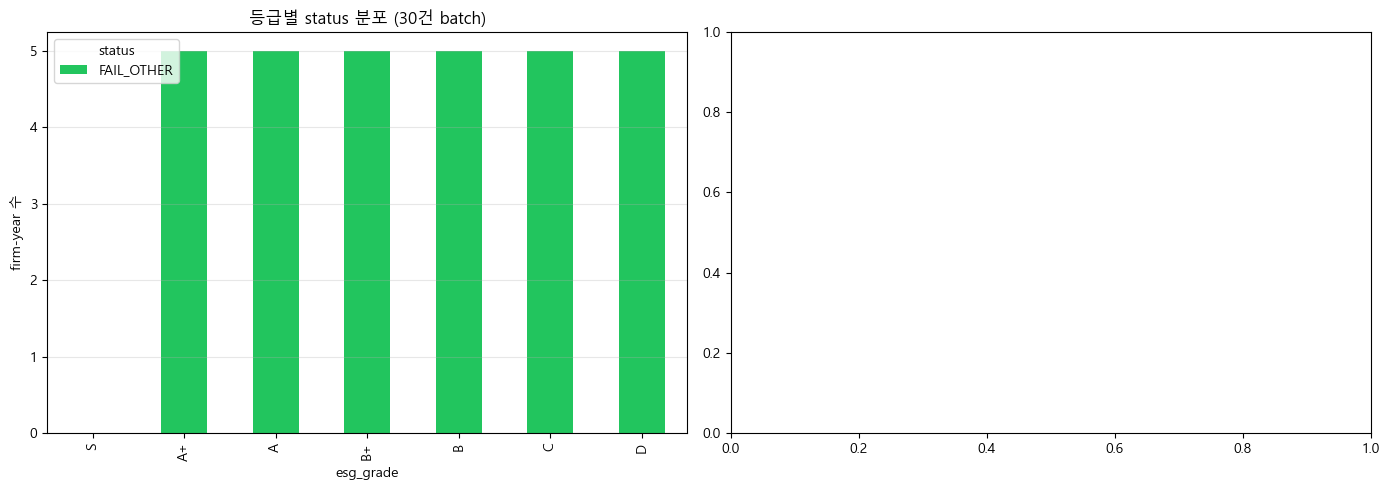


📋 phase2B v1 self-check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                       항목         결과                                      근거
0                  30건 시도         30  stratified 5건 × 7등급 = 35 목표 (S 부족 시 ↓)
1                 SUCCESS  0/30 (0%)                               ⚠️ 80% 미달
2        WARN_NO_PASSAGES          0        sections OK but seed 0건 — 보고서 기록
3                  FAIL_*         30                     실패 이유 reason 컬럼에 명시
4                   등급 분포  S~D 모두 충족                       Spearman 입력 분산 확보
5  Samsung 2024 (phase2A)        제외됨             collection_log에서 v2 행 별도 보존

🎯 다음 액션
   1. 사용자: random 3건 viewer 확인 (Step 5)
   2. 02_preprocessing_v2 재실행 → esg_features_v2.parquet (1행)
   3. 03_mining_v1 재실행 → Spearman·t-test·OLS 정상 통계
   4. 02b_s_score_diagnosis_v1 결과 + batch S 점수 비교


In [7]:
batch_with_grade = batch_log.merge(
    cm[['stock_code','fiscal_year','esg_grade','company_name']].astype({'stock_code':str}),
    on=['stock_code','fiscal_year'], how='left'
)

# 등급 × status crosstab
ct = pd.crosstab(batch_with_grade['esg_grade'], batch_with_grade['status'])
ct = ct.reindex(['S','A+','A','B+','B','C','D']).fillna(0).astype(int)
print(f'📊 등급 × status crosstab')
print(ct.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct.plot(kind='bar', stacked=True, ax=axes[0],
        color=['#22c55e', '#f59e0b', '#ef4444', '#94a3b8'][:len(ct.columns)])
axes[0].set_title(f'등급별 status 분포 ({len(batch_log)}건 batch)')
axes[0].set_ylabel('firm-year 수')
axes[0].legend(title='status')
axes[0].grid(axis='y', alpha=0.3)

# n_passages_body 분포
success = batch_with_grade[batch_with_grade['status']=='SUCCESS']
if len(success) > 0:
    success.boxplot(column='n_passages_body', by='esg_grade', ax=axes[1],
                    grid=True, return_type='axes')
    axes[1].set_title('등급별 n_passages_body 분포 (SUCCESS만)')
    axes[1].set_ylabel('passage 수')
    axes[1].set_xlabel('esg_grade')

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_v3_batch_grade_status.png', dpi=120)
plt.show()

# self-check
print(f'\n📋 phase2B v1 self-check')
print(f'━' * 70)
n_total = len(batch_log)
n_succ = (batch_log['status']=='SUCCESS').sum()
n_warn = batch_log['status'].str.startswith('WARN').sum()
n_fail = batch_log['status'].str.startswith('FAIL').sum()

checks = [
    ('30건 시도', f'{n_total}', f'stratified 5건 × 7등급 = 35 목표 (S 부족 시 ↓)'),
    ('SUCCESS', f'{n_succ}/{n_total} ({n_succ/max(1,n_total)*100:.0f}%)',
     '✅' if n_succ/max(1,n_total) >= 0.8 else '⚠️ 80% 미달'),
    ('WARN_NO_PASSAGES', f'{n_warn}', 'sections OK but seed 0건 — 보고서 기록'),
    ('FAIL_*', f'{n_fail}', '실패 이유 reason 컬럼에 명시'),
    ('등급 분포', f'S~D 모두 충족' if (ct.sum(axis=1) > 0).sum() >= 5 else '⚠️ 일부 등급 0건',
     'Spearman 입력 분산 확보'),
    ('Samsung 2024 (phase2A)', '제외됨', 'collection_log에서 v2 행 별도 보존'),
]
print(pd.DataFrame(checks, columns=['항목','결과','근거']).to_string())

print(f'\n🎯 다음 액션')
print(f'   1. 사용자: random 3건 viewer 확인 (Step 5)')
print(f'   2. 02_preprocessing_v2 재실행 → esg_features_v2.parquet ({n_succ+1}행)')
print(f'   3. 03_mining_v1 재실행 → Spearman·t-test·OLS 정상 통계')
print(f'   4. 02b_s_score_diagnosis_v1 결과 + batch S 점수 비교')
